In [21]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

# Search for WASP-17 - a hot Jupiter with a very deep, easy to detect transit
search_result = lk.search_lightcurve("WASP-17", mission="TESS", author="SPOC", exptime=120)
print(f"Found {len(search_result)} sectors")
print(search_result)

Found 3 sectors
SearchResult containing 3 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 12 2019   SPOC     120    66818296      0.0
  1 TESS Sector 38 2021   SPOC     120    66818296      0.0
  2 TESS Sector 91 2025   SPOC     120    66818296      0.0


Total data points: 51066


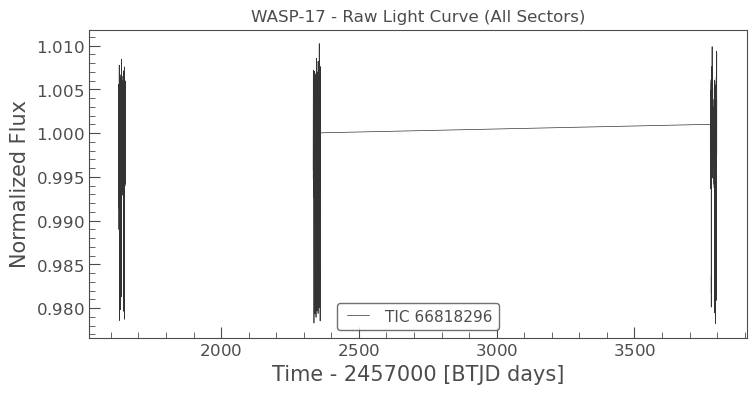

In [22]:
# Download all sectors and stitch
lc_collection = search_result.download_all()
lc_stitched = lc_collection.stitch()

# Normalize only - no flattening to preserve transit shape
lc_clean = lc_stitched.normalize()

print(f"Total data points: {len(lc_clean)}")
lc_clean.plot()
plt.title("WASP-17 - Raw Light Curve (All Sectors)")
plt.show()

`period` contains 4393285 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


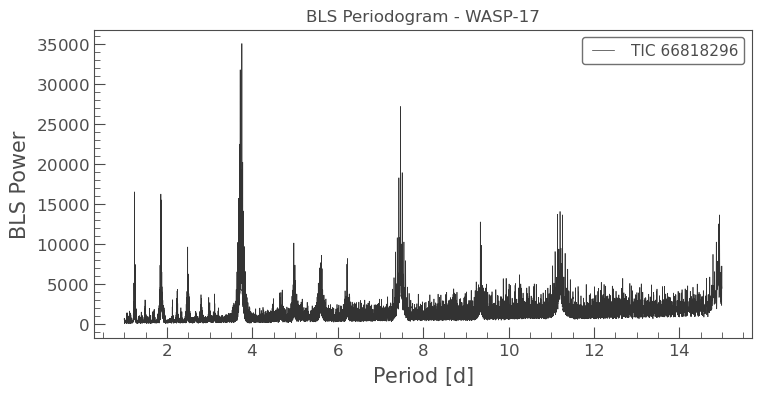

Best period found: 3.7550 d days
Known WASP-17b period: 3.7354 days


In [23]:
# Run BLS - manageable dataset size this time
periodogram = lc_clean.to_periodogram(
    method='bls',
    period=np.arange(1, 15, 0.001),
    duration=np.arange(0.1, 0.5, 0.05)
)

periodogram.plot()
plt.title("BLS Periodogram - WASP-17")
plt.show()

best_period = periodogram.period_at_max_power
print(f"Best period found: {best_period:.4f} days")
print(f"Known WASP-17b period: 3.7354 days")

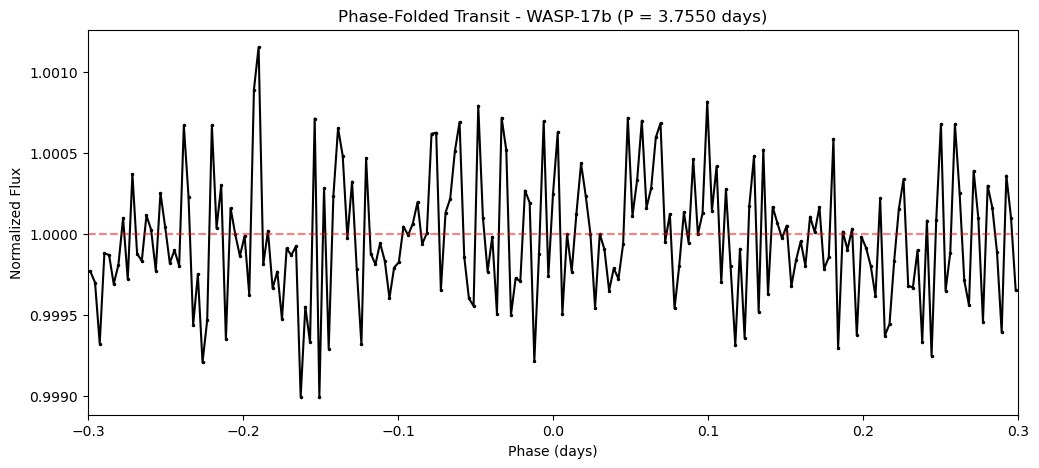

In [24]:
# Phase fold at detected period
period = best_period.value
lc_folded = lc_clean.fold(period=period)

phase = lc_folded.time.value
flux = lc_folded.flux.value

sort_idx = np.argsort(phase)
phase_sorted = phase[sort_idx]
flux_sorted = flux[sort_idx]

bins = np.linspace(-0.3, 0.3, 200)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_flux = np.array([np.median(flux_sorted[(phase_sorted >= bins[i]) & 
                     (phase_sorted < bins[i+1])]) 
                     for i in range(len(bins)-1)])

plt.figure(figsize=(12, 5))
plt.plot(bin_centers, bin_flux, 'k.-', linewidth=1.5, markersize=3)
plt.axhline(1.0, color='r', linestyle='--', alpha=0.5)
plt.xlabel("Phase (days)")
plt.ylabel("Normalized Flux")
plt.title(f"Phase-Folded Transit - WASP-17b (P = {period:.4f} days)")
plt.xlim(-0.3, 0.3)
plt.show()

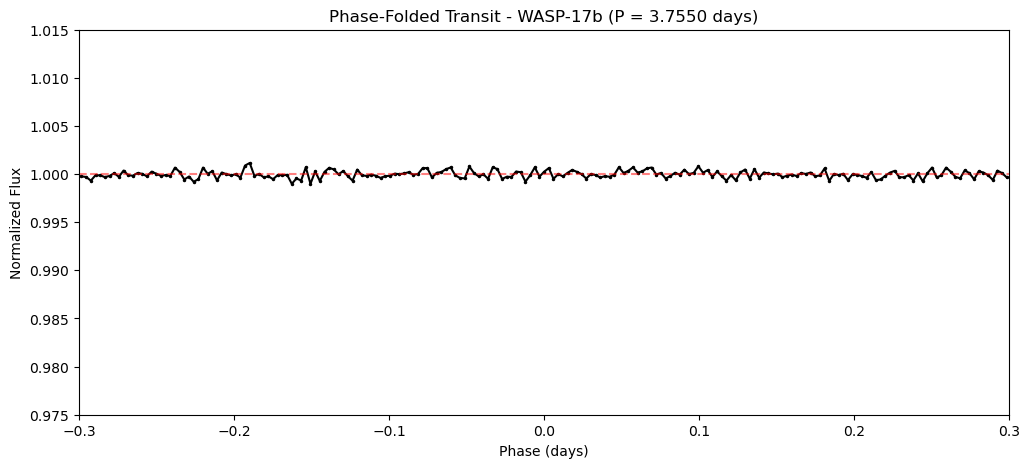

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(bin_centers, bin_flux, 'k.-', linewidth=1.5, markersize=3)
plt.axhline(1.0, color='r', linestyle='--', alpha=0.5)
plt.xlabel("Phase (days)")
plt.ylabel("Normalized Flux")
plt.title(f"Phase-Folded Transit - WASP-17b (P = {period:.4f} days)")
plt.xlim(-0.3, 0.3)
plt.ylim(0.975, 1.015)
plt.show()

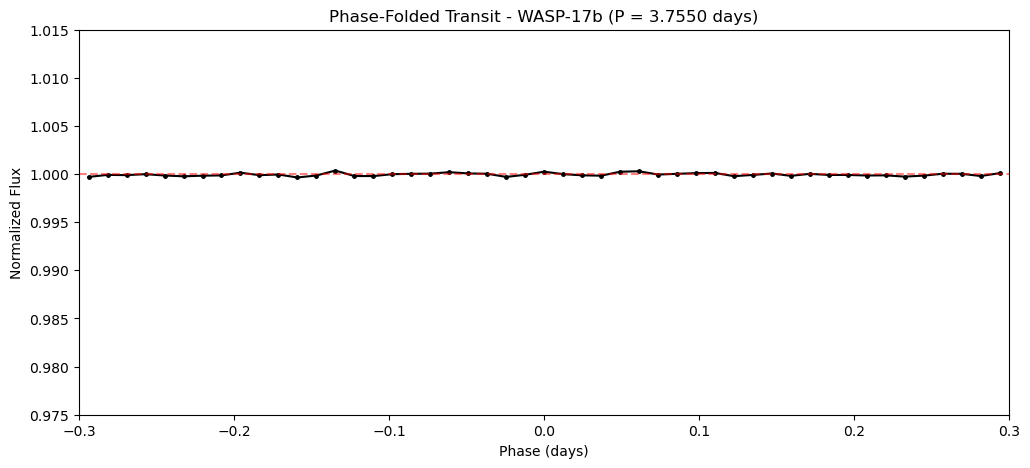

In [26]:
# Use fewer, wider bins
bins = np.linspace(-0.3, 0.3, 50)  # 50 bins instead of 200
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_flux = np.array([np.median(flux_sorted[(phase_sorted >= bins[i]) & 
                     (phase_sorted < bins[i+1])]) 
                     for i in range(len(bins)-1)])

plt.figure(figsize=(12, 5))
plt.plot(bin_centers, bin_flux, 'k.-', linewidth=1.5, markersize=5)
plt.axhline(1.0, color='r', linestyle='--', alpha=0.5)
plt.xlabel("Phase (days)")
plt.ylabel("Normalized Flux")
plt.title(f"Phase-Folded Transit - WASP-17b (P = {period:.4f} days)")
plt.xlim(-0.3, 0.3)
plt.ylim(0.975, 1.015)
plt.show()

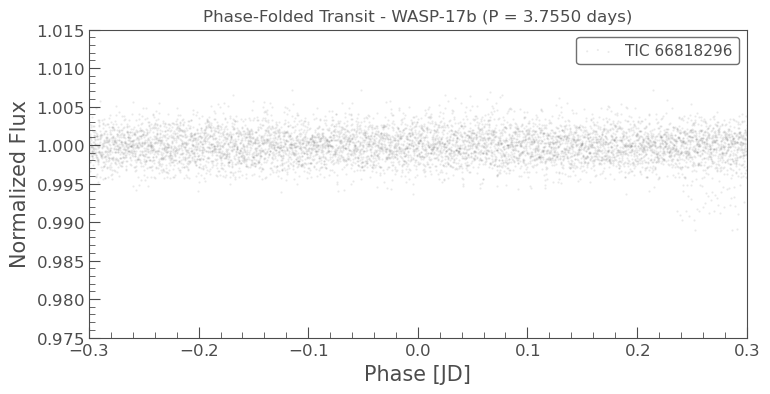

In [27]:
# Use lightkurve's fold directly on the full clean data
lc_folded = lc_clean.fold(period=period)
lc_folded.scatter(alpha=0.1, s=1)
plt.title(f"Phase-Folded Transit - WASP-17b (P = {period:.4f} days)")
plt.xlim(-0.3, 0.3)
plt.ylim(0.975, 1.015)
plt.show()

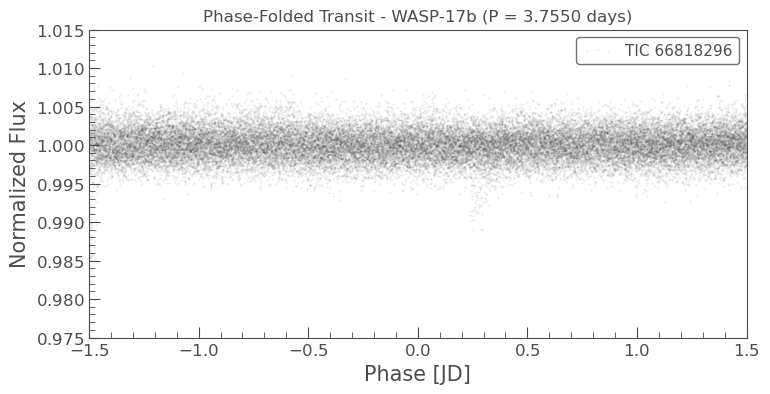

In [28]:
lc_folded = lc_clean.fold(period=period)
lc_folded.scatter(alpha=0.1, s=1)
plt.title(f"Phase-Folded Transit - WASP-17b (P = {period:.4f} days)")
plt.xlim(-1.5, 1.5)  # much wider window
plt.ylim(0.975, 1.015)
plt.show()

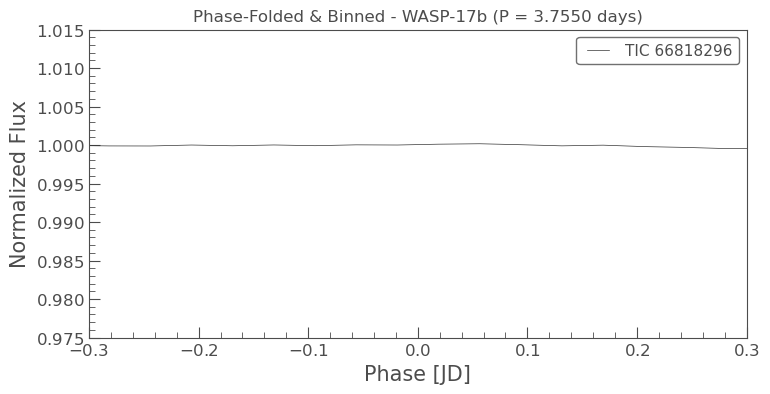

In [29]:
# Use lightkurve's fold with built-in binning
lc_folded = lc_clean.fold(period=period)
lc_folded_binned = lc_folded.bin(bins=100)

lc_folded_binned.plot()
plt.title(f"Phase-Folded & Binned - WASP-17b (P = {period:.4f} days)")
plt.xlim(-0.3, 0.3)
plt.ylim(0.975, 1.015)
plt.show()

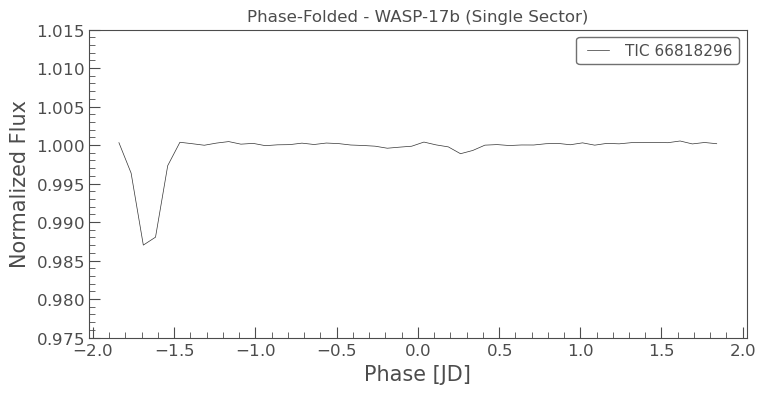

In [30]:
# Download just one sector - no stitching
lc_single = search_result[0].download()

# Normalize only
lc_single_norm = lc_single.normalize()

# Fold at detected period
lc_folded = lc_single_norm.fold(period=period)
lc_folded_binned = lc_folded.bin(bins=50)

lc_folded_binned.plot()
plt.title("Phase-Folded - WASP-17b (Single Sector)")
plt.ylim(0.975, 1.015)
plt.show()

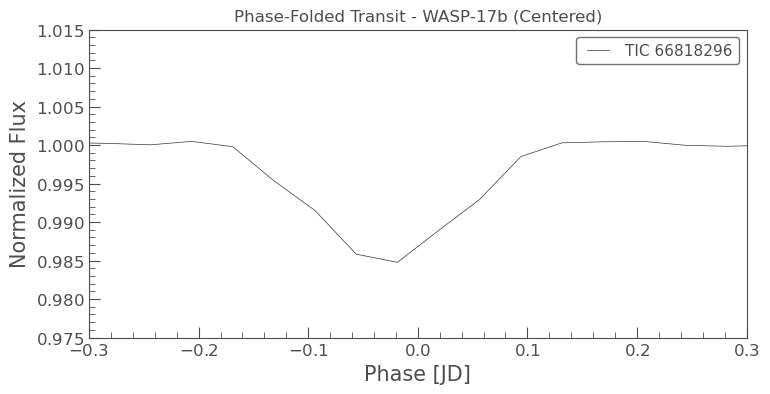

In [31]:
# Find the t0 from the BLS result and use it to center the fold
t0 = periodogram.transit_time_at_max_power

lc_folded_centered = lc_single_norm.fold(period=period, epoch_time=t0)
lc_folded_binned = lc_folded_centered.bin(bins=100)

lc_folded_binned.plot()
plt.title("Phase-Folded Transit - WASP-17b (Centered)")
plt.xlim(-0.3, 0.3)
plt.ylim(0.975, 1.015)
plt.show()

Total data points: 51066


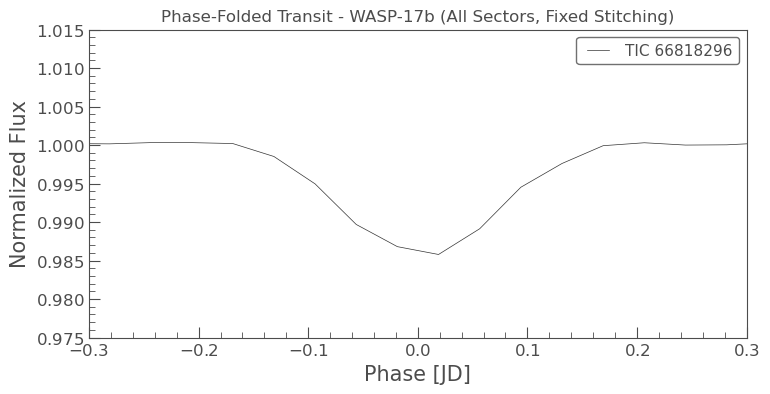

In [32]:
# Normalize each sector individually before stitching
lc_list = []
for lc in lc_collection:
    lc_norm = lc.normalize()
    lc_list.append(lc_norm)

# Stitch the pre-normalized light curves
from lightkurve import LightCurveCollection
lc_stitched_fixed = LightCurveCollection(lc_list).stitch()

print(f"Total data points: {len(lc_stitched_fixed)}")

# Fold and bin
lc_folded = lc_stitched_fixed.fold(period=period, epoch_time=t0)
lc_folded_binned = lc_folded.bin(bins=100)

lc_folded_binned.plot()
plt.title("Phase-Folded Transit - WASP-17b (All Sectors, Fixed Stitching)")
plt.xlim(-0.3, 0.3)
plt.ylim(0.975, 1.015)
plt.show()

`period` contains 3671549 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


Searching for WASP-17...
Found 3 sectors. Downloading...
Running transit search...
Best period: 3.7355 days
Transit depth: 1.54%


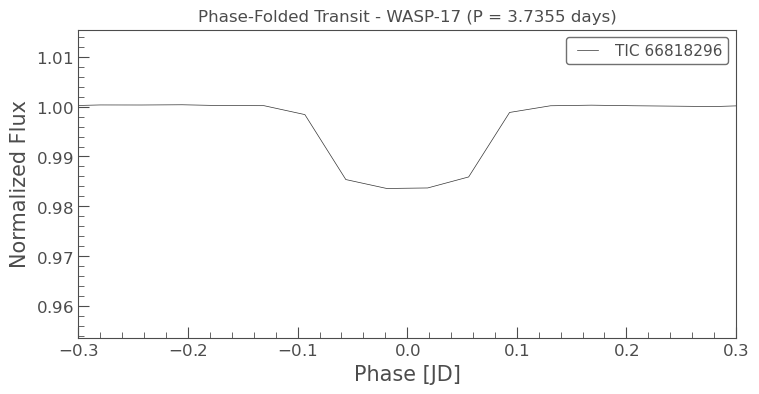

In [35]:
# Generalize into a function for any star
def detect_transit(star_name, max_period=20):
    print(f"Searching for {star_name}...")
    search = lk.search_lightcurve(star_name, mission="TESS", author="SPOC", exptime=120)
    
    if len(search) == 0:
        print("No TESS data found for this star.")
        return
    
    print(f"Found {len(search)} sectors. Downloading...")
    collection = search.download_all()
    
    lc_list = [lc.normalize() for lc in collection]
    lc_stitched = LightCurveCollection(lc_list).stitch()
    
    print("Running transit search...")
    periodogram = lc_stitched.to_periodogram(
        method='bls',
        minimum_period=0.5,
        maximum_period=max_period,
        frequency_factor=50,  # higher = coarser grid = faster
        duration=np.arange(0.05, 0.5, 0.1)
    )
    
    best_period = periodogram.period_at_max_power.value
    t0 = periodogram.transit_time_at_max_power
    depth = periodogram.depth_at_max_power
    
    print(f"Best period: {best_period:.4f} days")
    print(f"Transit depth: {depth*100:.2f}%")
    
    lc_folded = lc_stitched.fold(period=best_period, epoch_time=t0)
    lc_folded.bin(bins=100).plot()
    plt.title(f"Phase-Folded Transit - {star_name} (P = {best_period:.4f} days)")
    plt.xlim(-0.3, 0.3)
    plt.ylim(1 - depth*3, 1 + depth)
    plt.show()

detect_transit("WASP-17")

Searching for HAT-P-7...
Found 10 sectors. Downloading...


`period` contains 2744795 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


Running transit search...
Best period: 2.2047 days
Transit depth: 0.59%


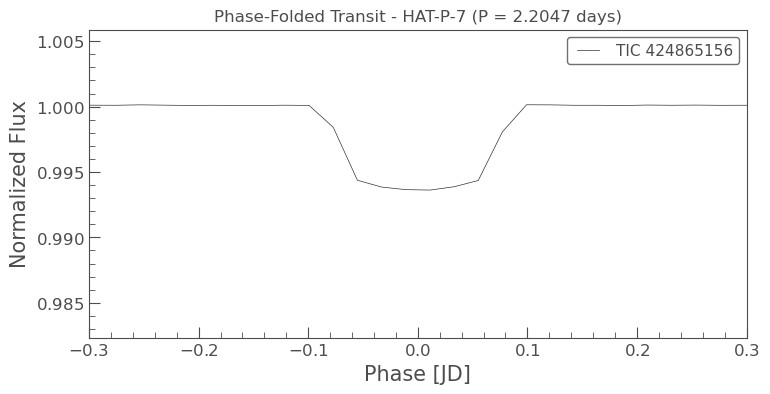

In [36]:
# test on a star without known transits
detect_transit("HAT-P-7")
